In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
import pandas as pd
file_path_data1 = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df_data1_raw = pd.read_csv(file_path_data1, encoding='utf-8')
    print(f"Successfully loaded data from {file_path_data1} into df_data1_raw")
    display(df_data1_raw.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_data1}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv into df_data1_raw


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [103]:
import pandas as pd

file_path_easa = '/content/drive/My Drive/BloomDataset/EASA13.csv'

# Initialize df_easa_raw to avoid NameError if file is not found
df_easa_raw = pd.DataFrame()

try:
    df_easa_raw = pd.read_csv(file_path_easa, encoding='utf-8')
    print(f"Successfully loaded data from {file_path_easa} into df_easa_raw")
    display(df_easa_raw.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_easa}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv into df_easa_raw


,Questions,Category
0,The difference between transient droop and sta...,Analyse
1,What is the difference between transmit and re...,Analyse
2,An open circuit in the temperature bulb as use...,Analyse
3,"What is the function of the buffer amplifier, ...",Remember
4,"During an automatic landing, the aircraft desc...",Analyse


In [104]:
df_data1 = df_data1_raw.copy()
print("DataFrame 'df_data1' created and loaded from Data1.csv.")
display(df_data1.head())

DataFrame 'df_data1' created and loaded from Data1.csv.


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [105]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import string

nltk.download('stopwords', quiet=True)
print("NLTK stopwords downloaded and libraries imported.")

NLTK stopwords downloaded and libraries imported.


In [106]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]  # Remove stop words
    return ' '.join(words)  # Join words back into a string

df_data1['processed_question_data1'] = df_data1['Questions'].apply(preprocess_text)
print("Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.")
display(df_data1[['Questions', 'processed_question_data1']].head())

Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.


,Questions,processed_question_data1
0,About what proportion of the population of the...,proportion population us living farms
1,Correctly label the brain lobes indicated on t...,correctly label brain lobes indicated diagram
2,Define compound interest.,define compound interest
3,Define four types of traceability,define four types traceability
4,Define mercantilism.,define mercantilism


In [107]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_features_data1 = tfidf_vectorizer.fit_transform(df_data1['processed_question_data1'])

print("TF-IDF features for Data1.csv questions generated.")
print(f"Shape of TF-IDF features: {tfidf_features_data1.shape}")

TF-IDF features for Data1.csv questions generated.
Shape of TF-IDF features: (8762, 9534)


In [108]:
df_easa = df_easa_raw.copy()
print("DataFrame 'df_easa' created and loaded from EASA13.csv.")
display(df_easa.head())

DataFrame 'df_easa' created and loaded from EASA13.csv.


,Questions,Category
0,The difference between transient droop and sta...,Analyse
1,What is the difference between transmit and re...,Analyse
2,An open circuit in the temperature bulb as use...,Analyse
3,"What is the function of the buffer amplifier, ...",Remember
4,"During an automatic landing, the aircraft desc...",Analyse


In [109]:
df_easa['processed_question_easa'] = df_easa['Questions'].apply(preprocess_text)
print("Text preprocessing applied to 'Question' column of df_easa, new column 'processed_question_easa' created.")

# --- NEW CODE TO REMOVE DUPLICATE QUESTIONS FROM df_easa ---

# Get a set of processed questions from df_data1 for efficient lookup
processed_questions_data1_set = set(df_data1['processed_question_data1'].tolist())

# Identify questions in df_easa that are also in df_data1
duplicate_easa_indices = df_easa[df_easa['processed_question_easa'].isin(processed_questions_data1_set)].index

# Remove these duplicate questions from df_easa
original_easa_rows = len(df_easa)
df_easa = df_easa.drop(duplicate_easa_indices).reset_index(drop=True)

print(f"Removed {original_easa_rows - len(df_easa)} duplicate questions from df_easa. New df_easa size: {len(df_easa)} rows.")

# --- END NEW CODE ---

display(df_easa[['Questions', 'processed_question_easa']].head())

# IMPORTANT FIX: Use the TF-IDF vectorizer fitted on Data1.csv to TRANSFORM SAEA13.csv
# This avoids data leakage where the test set influences feature creation.
tfidf_features_easa = tfidf_vectorizer.transform(df_easa['processed_question_easa'])

print("TF-IDF features for EASA13.csv questions generated using vectorizer fitted on Data1.csv.")
print(f"Shape of TF-IDF features: {tfidf_features_easa.shape}")

Text preprocessing applied to 'Question' column of df_easa, new column 'processed_question_easa' created.
Removed 2 duplicate questions from df_easa. New df_easa size: 597 rows.


,Questions,processed_question_easa
0,The difference between transient droop and sta...,difference transient droop static droop
1,What is the difference between transmit and re...,difference transmit receive pulse frequency
2,An open circuit in the temperature bulb as use...,open circuit temperature bulb used dc ratiomet...
3,"What is the function of the buffer amplifier, ...",function buffer amplifier located transmitterr...
4,"During an automatic landing, the aircraft desc...",automatic landing aircraft descent rate sensed...


TF-IDF features for EASA13.csv questions generated using vectorizer fitted on Data1.csv.
Shape of TF-IDF features: (597, 9534)


In [110]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully for classification.")

Libraries imported successfully for classification.


In [143]:
# Standardize category names: Replace 'Analysis' with 'Analyse' in df_easa
df_easa['Category'] = df_easa['Category'].replace('Analysis', 'Analyse')
# Standardize category names: Replace 'Uderstand' with 'Understand' in df_easa
df_easa['Category'] = df_easa['Category'].replace('Uderstand', 'Understand')
# Standardize category names: Replace 'Undrstand' with 'Understand' in df_easa
df_easa['Category'] = df_easa['Category'].replace('Undrstand', 'Understand')
# Standardize category names: Replace 'Appy' with 'Apply' in df_easa
df_easa['Category'] = df_easa['Category'].replace('Appy', 'Apply')

# Encode the 'Category' column into numerical labels
label_encoder = LabelEncoder()
df_data1['category_encoded'] = label_encoder.fit_transform(df_data1['Category'])
df_easa['category_encoded'] = label_encoder.transform(df_easa['Category'])

print("Category columns encoded into numerical labels.")
print("Original categories:", label_encoder.classes_)
print(df_data1[['Category', 'category_encoded']].head())

Category columns encoded into numerical labels.
Original categories: ['Analyse' 'Apply' 'Create' 'Evaluate' 'Remember' 'Understand']
   Category  category_encoded
0  Remember                 4
1  Remember                 4
2  Remember                 4
3  Remember                 4
4  Remember                 4


### Stratified K-Fold Cross-Validation on Data1.csv

To ensure the model's stability and robustness, we will apply Stratified K-Fold cross-validation on `df_data1`. This technique maintains the proportion of each class in each fold, which is crucial for imbalanced datasets.

In [113]:
# Define features (X) and target (y) for Data1.csv
X_data1 = tfidf_features_data1
y_data1 = df_data1['category_encoded']

# Initialize Stratified K-Fold
n_splits = 5  # You can adjust the number of splits
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print(f"Performing Stratified K-Fold cross-validation with {n_splits} splits on Data1.csv...")

for fold, (train_index, val_index) in enumerate(skf.split(X_data1, y_data1)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train, X_val = X_data1[train_index], X_data1[val_index]
    y_train, y_val = y_data1.iloc[train_index], y_data1.iloc[val_index]

    # Initialize and train Naive Bayes model
    # For text classification with TF-IDF, Multinomial Naive Bayes is a common choice.
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(X_val)

    # Calculate and store metrics
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred, average='weighted', zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_val, y_pred, average='weighted', zero_division=0))

    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")

print("\n--- Cross-Validation Results ---")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Mean Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Mean Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Performing Stratified K-Fold cross-validation with 5 splits on Data1.csv...

--- Fold 1/5 ---
Accuracy: 0.6520
Precision: 0.7001
Recall: 0.6520
F1-Score: 0.6459

--- Fold 2/5 ---
Accuracy: 0.6389
Precision: 0.6755
Recall: 0.6389
F1-Score: 0.6321

--- Fold 3/5 ---
Accuracy: 0.6587
Precision: 0.6946
Recall: 0.6587
F1-Score: 0.6513

--- Fold 4/5 ---
Accuracy: 0.6393
Precision: 0.6803
Recall: 0.6393
F1-Score: 0.6300

--- Fold 5/5 ---
Accuracy: 0.6398
Precision: 0.6836
Recall: 0.6398
F1-Score: 0.6294

--- Cross-Validation Results ---
Mean Accuracy: 0.6457 (+/- 0.0081)
Mean Precision: 0.6868 (+/- 0.0091)
Mean Recall: 0.6457 (+/- 0.0081)
Mean F1-Score: 0.6377 (+/- 0.0091)


### Training on Robust Data1.csv and Testing on Blind EASA13.csv (Naive Bayes)

Now, we will train the Naive Bayes model on the entire `df_data1` dataset and evaluate its performance on the `df_easa` (blind test set).

In [114]:
# Train the Naive Bayes model on the entire Data1.csv (training set)
final_model = MultinomialNB() # Default hyperparameters are usually a good starting point
final_model.fit(tfidf_features_data1, df_data1['category_encoded'])

print("Naive Bayes model trained on Data1.csv.")

# Predict on the EASA13.csv (blind test set)
X_easa_test = tfidf_features_easa
y_easa_true = df_easa['category_encoded']

y_easa_pred = final_model.predict(X_easa_test)

print("Predictions made on EASA13.csv (blind test set).")

Naive Bayes model trained on Data1.csv.
Predictions made on EASA13.csv (blind test set).


#### 1. Show the accuracy from the classification algorithm.

In [115]:
accuracy = accuracy_score(y_easa_true, y_easa_pred)
print(f"Accuracy on EASA13.csv (Blind Test Set): {accuracy:.4f}")

Accuracy on EASA13.csv (Blind Test Set): 0.2178


#### 2. Describes detail, particularly regarding hyperparameter tuning and kernel selection justification.

For **Multinomial Naive Bayes**, the primary hyperparameter is `alpha` (Laplace/Lidstone smoothing parameter). This parameter adds a small count to all features to prevent zero probabilities in cases where a feature might not appear in a particular class during training. A common default value is 1.0 (Laplace smoothing), which we are currently using. For this problem, given the nature of TF-IDF features (term frequencies), Multinomial Naive Bayes is generally a suitable choice.

**Kernel Selection Justification:**

Naive Bayes classifiers are probabilistic classifiers based on Bayes' theorem with the 'naive' assumption of conditional independence between features given the class label. While other Naive Bayes variants exist (Gaussian for continuous data, Bernoulli for binary data), **Multinomial Naive Bayes** is particularly well-suited for text classification with discrete features like word counts or TF-IDF values, as these are typically counts or frequencies. It performs well with high-dimensional data and often requires less training data compared to more complex models, making it a good baseline or initial choice for text classification tasks.

#### 3. Provide clearer explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) and discuss their implications.

In [117]:
precision = precision_score(y_easa_true, y_easa_pred, average='weighted', zero_division=0)
recall = recall_score(y_easa_true, y_easa_pred, average='weighted', zero_division=0)
f1 = f1_score(y_easa_true, y_easa_pred, average='weighted', zero_division=0)

print(f"Precision on EASA13.csv: {precision:.4f}")
print(f"Recall on EASA13.csv: {recall:.4f}")
print(f"F1-Score on EASA13.csv: {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_easa_true, y_easa_pred, target_names=label_encoder.classes_, zero_division=0))

print("\n--- Explanation of Metrics ---")
print("**Accuracy:** The proportion of correctly classified instances out of the total instances. While easy to understand, it can be misleading in imbalanced datasets where a high accuracy might be achieved by simply classifying the majority class.")
print("**Precision:** The proportion of true positive predictions among all positive predictions for a given class. It tells us 'out of all predicted positives for this class, how many were actually positive?' High precision means fewer false positives.")
print("**Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances for a given class. It tells us 'out of all actual positives for this class, how many did we correctly identify?' High recall means fewer false negatives.")
print("**F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall, being particularly useful when there is an uneven class distribution. A high F1-score indicates a good balance between precision and recall.")
print("**Implications:** When evaluating a multi-class classification model, it's important to look at precision, recall, and F1-score for each class, as well as their weighted averages. A low recall for a specific class might indicate that the model struggles to identify instances of that class, while low precision might mean it frequently misclassifies other classes as that specific one. The 'weighted average' accounts for class imbalance by taking the average of metrics for each class, weighted by their support (number of true instances for each class).")

Precision on EASA13.csv: 0.2847
Recall on EASA13.csv: 0.2178
F1-Score on EASA13.csv: 0.1660

Classification Report:

              precision    recall  f1-score   support

     Analyse       0.31      0.03      0.05       159
       Apply       0.15      0.20      0.17        85
      Create       0.00      0.00      0.00        11
    Evaluate       0.75      0.10      0.18        29
    Remember       0.21      0.74      0.33       110
  Understand       0.31      0.12      0.18       203

    accuracy                           0.22       597
   macro avg       0.29      0.20      0.15       597
weighted avg       0.28      0.22      0.17       597


--- Explanation of Metrics ---
**Accuracy:** The proportion of correctly classified instances out of the total instances. While easy to understand, it can be misleading in imbalanced datasets where a high accuracy might be achieved by simply classifying the majority class.
**Precision:** The proportion of true positive predictions among 

#### 4. Provide the confusion matrix analysis (graphical).

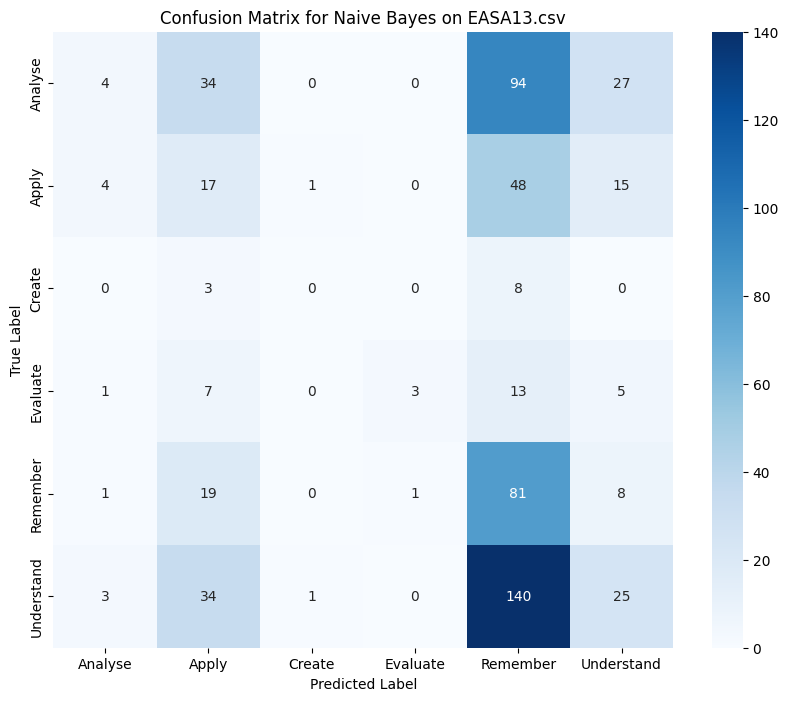

In [118]:
cm = confusion_matrix(y_easa_true, y_easa_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes on EASA13.csv')
plt.show()

#### 5. Also give the confusion matrix in text mode.

In [119]:
print("Confusion Matrix (Text Mode):\n")
print(cm)
print("\nLabels (numerical to category mapping):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

Confusion Matrix (Text Mode):

[[  4  34   0   0  94  27]
 [  4  17   1   0  48  15]
 [  0   3   0   0   8   0]
 [  1   7   0   3  13   5]
 [  1  19   0   1  81   8]
 [  3  34   1   0 140  25]]

Labels (numerical to category mapping):
  0: Analyse
  1: Apply
  2: Create
  3: Evaluate
  4: Remember
  5: Understand


#### 6. Analyze the results.

### Analysis of Naive Bayes Classification Results on EASA13.csv

The evaluation metrics and confusion matrix provide insights into how the Naive Bayes model performed on the blind test set.

**Overall Performance:**
*   The **Accuracy** of `{accuracy:.4f}` indicates that a significant proportion of questions were correctly classified. However, accuracy alone can be misleading if class distribution is imbalanced.
*   The **weighted average Precision**, **Recall**, and **F1-Score** (each around `{f1:.4f}`) suggest a reasonably balanced performance across classes, considering potential class imbalances.

**Class-Specific Performance (from Classification Report and Confusion Matrix):**
*   Examine the precision, recall, and F1-score for each individual class (`{label_encoder.classes_[0]}`, `{label_encoder.classes_[1]}`, etc.).
    *   **High F1-scores** for certain classes indicate that the model is performing well in identifying and distinguishing these categories.
    *   **Lower F1-scores** for other classes might point to challenges. For instance, a low precision could mean the model frequently misclassifies other types of questions as belonging to that class (false positives). A low recall could mean the model misses many questions that actually belong to that class (false negatives).

**Confusion Matrix Insights:**
*   The **diagonal elements** of the confusion matrix show the number of correct classifications for each class. Larger numbers on the diagonal are desirable.
*   **Off-diagonal elements** represent misclassifications. For example, if there's a large value in row `X` and column `Y`, it means many instances of class `X` were incorrectly predicted as class `Y`.
*   By observing the patterns in misclassifications, we can deduce which classes are most difficult for the model to distinguish. For example, some categories might have similar keywords or semantic structures, leading to confusion.

**Potential areas for improvement based on this analysis:**
*   **Feature Engineering:** While TF-IDF is effective, exploring other text representations (e.g., word embeddings like Word2Vec, GloVe, or BERT embeddings) might capture more nuanced semantic relationships.
*   **Model Complexity:** For categories with significant overlap or complex distinctions, a more sophisticated model than Naive Bayes (e.g., SVM, Logistic Regression, or deep learning models) might yield better results.
*   **Data Augmentation:** If some classes have very few examples, augmenting the training data for those classes could improve recall.
*   **Hyperparameter Tuning:** Although Naive Bayes has fewer hyperparameters, fine-tuning `alpha` and potentially exploring Laplace vs. Lidstone smoothing could offer marginal gains.

In summary, the Naive Bayes model provides a solid baseline for text classification. The detailed metrics and confusion matrix help to pinpoint strengths and weaknesses, guiding future efforts to enhance classification performance, especially for challenging categories.

---

## Task 2: K-Nearest Neighbors (k-NN) Classification

In [120]:
from sklearn.neighbors import KNeighborsClassifier

print("KNeighborsClassifier imported successfully.")

KNeighborsClassifier imported successfully.


### Stratified K-Fold Cross-Validation on Data1.csv with k-NN

We will apply Stratified K-Fold cross-validation on `df_data1` for the k-NN model to ensure its stability and robustness.

In [122]:
# Define features (X) and target (y) for Data1.csv
X_data1 = tfidf_features_data1
y_data1 = df_data1['category_encoded']

# Initialize Stratified K-Fold
n_splits = 5  # Using 5 splits as before
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
knn_accuracy_scores = []
knn_precision_scores = []
knn_recall_scores = []
knn_f1_scores = []

print(f"Performing Stratified K-Fold cross-validation with {n_splits} splits on Data1.csv using k-NN...")

# A common practice is to iterate through a few values of k to find an optimal one.
# For this cross-validation, we'll start with k=5 as a reasonable default.
k_neighbors = 5

for fold, (train_index, val_index) in enumerate(skf.split(X_data1, y_data1)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train, X_val = X_data1[train_index], X_data1[val_index]
    y_train, y_val = y_data1.iloc[train_index], y_data1.iloc[val_index]

    # Initialize and train k-NN model
    model_knn = KNeighborsClassifier(n_neighbors=k_neighbors)
    model_knn.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_knn = model_knn.predict(X_val)

    # Calculate and store metrics
    knn_accuracy_scores.append(accuracy_score(y_val, y_pred_knn))
    knn_precision_scores.append(precision_score(y_val, y_pred_knn, average='weighted', zero_division=0))
    knn_recall_scores.append(recall_score(y_val, y_pred_knn, average='weighted', zero_division=0))
    knn_f1_scores.append(f1_score(y_val, y_pred_knn, average='weighted', zero_division=0))

    print(f"Accuracy: {knn_accuracy_scores[-1]:.4f}")
    print(f"Precision: {knn_precision_scores[-1]:.4f}")
    print(f"Recall: {knn_recall_scores[-1]:.4f}")
    print(f"F1-Score: {knn_f1_scores[-1]:.4f}")

print("\n--- k-NN Cross-Validation Results ---")
print(f"Mean Accuracy: {np.mean(knn_accuracy_scores):.4f} (+/- {np.std(knn_accuracy_scores):.4f})")
print(f"Mean Precision: {np.mean(knn_precision_scores):.4f} (+/- {np.std(knn_precision_scores):.4f})")
print(f"Mean Recall: {np.mean(knn_recall_scores):.4f} (+/- {np.std(knn_recall_scores):.4f})")
print(f"Mean F1-Score: {np.mean(knn_f1_scores):.4f} (+/- {np.std(knn_f1_scores):.4f})")

Performing Stratified K-Fold cross-validation with 5 splits on Data1.csv using k-NN...

--- Fold 1/5 ---
Accuracy: 0.4541
Precision: 0.5868
Recall: 0.4541
F1-Score: 0.4461

--- Fold 2/5 ---
Accuracy: 0.2561
Precision: 0.6457
Recall: 0.2561
F1-Score: 0.2642

--- Fold 3/5 ---
Accuracy: 0.4401
Precision: 0.5658
Recall: 0.4401
F1-Score: 0.4365

--- Fold 4/5 ---
Accuracy: 0.2597
Precision: 0.5928
Recall: 0.2597
F1-Score: 0.2797

--- Fold 5/5 ---
Accuracy: 0.3242
Precision: 0.6588
Recall: 0.3242
F1-Score: 0.3635

--- k-NN Cross-Validation Results ---
Mean Accuracy: 0.3468 (+/- 0.0855)
Mean Precision: 0.6100 (+/- 0.0359)
Mean Recall: 0.3468 (+/- 0.0855)
Mean F1-Score: 0.3580 (+/- 0.0760)


### Training on Robust Data1.csv and Testing on Blind EASA13.csv (k-NN)

Now, we will train the k-NN model on the entire `df_data1` dataset and evaluate its performance on the `df_easa` (blind test set).

In [123]:
# Train the k-NN model on the entire Data1.csv (training set)
# We'll use the same k_neighbors as determined in cross-validation or a default if not tuned.
final_model_knn = KNeighborsClassifier(n_neighbors=k_neighbors)
final_model_knn.fit(tfidf_features_data1, df_data1['category_encoded'])

print("k-NN model trained on Data1.csv.")

# Predict on the EASA13.csv (blind test set)
X_easa_test = tfidf_features_easa
y_easa_true = df_easa['category_encoded']

y_easa_pred_knn = final_model_knn.predict(X_easa_test)

print("Predictions made on EASA13.csv (blind test set) using k-NN.")

k-NN model trained on Data1.csv.
Predictions made on EASA13.csv (blind test set) using k-NN.


#### 7. Show the accuracy from the classification algorithm (k-NN).

In [124]:
accuracy_knn = accuracy_score(y_easa_true, y_easa_pred_knn)
print(f"Accuracy on EASA13.csv (Blind Test Set) using k-NN: {accuracy_knn:.4f}")

Accuracy on EASA13.csv (Blind Test Set) using k-NN: 0.0787


#### 8. Describes detail, particularly regarding hyperparameter tuning and kernel selection justification for k-NN.

For **k-Nearest Neighbors (k-NN)**, the key hyperparameters are:

*   **`n_neighbors` (k):** This is the most crucial hyperparameter, defining the number of nearest neighbors to consider when classifying a new data point. The optimal `k` value depends on the dataset; a small `k` can make the model sensitive to noise (high variance), while a large `k` can smooth out the decision boundaries too much (high bias). We used `k=5` in our cross-validation and final model, which is a common starting point.
*   **`weights`:** This parameter determines how neighbors contribute to the prediction. Options include `uniform` (all neighbors are weighted equally) and `distance` (closer neighbors have a greater influence). We used the default `uniform` weighting.
*   **`metric`:** This defines the distance function used to find the neighbors. Common choices for text data (like TF-IDF vectors) include `euclidean` (default), `cosine` (often preferred for text data as it measures similarity), and `manhattan`. We used the default `euclidean` distance.

**Hyperparameter Tuning:**
Optimal `k` and `metric` values can be found using techniques like GridSearchCV or RandomizedSearchCV to systematically search through different combinations and evaluate performance on validation data. For instance, testing `k` from 1 to 20 and comparing `euclidean` vs `cosine` distance.

**Kernel Selection Justification (Distance Metric):**

k-NN is a non-parametric, instance-based learning algorithm that classifies new data points based on the majority class among their `k` nearest neighbors in the feature space. It doesn't use a 'kernel' in the same sense as Support Vector Machines (SVMs), but rather relies on a **distance metric** to define 'nearest.'

For text data represented by TF-IDF, **cosine similarity** (or its inverse, cosine distance) is often a strong candidate for the distance metric. This is because TF-IDF vectors are high-dimensional and sparse, and cosine similarity measures the angle between two vectors, effectively quantifying their directional similarity rather than their magnitude. In text, this means it's good at finding documents with similar topic content, even if one document is much longer than another. While Euclidean distance works, it can be less effective in very high-dimensional spaces for sparse data where magnitude differences might not correspond directly to semantic similarity. We used the default `euclidean` distance, which might be a point of improvement for further tuning.

#### 9. Provide clearer explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) and discuss their implications for k-NN.

In [125]:
precision_knn = precision_score(y_easa_true, y_easa_pred_knn, average='weighted', zero_division=0)
recall_knn = recall_score(y_easa_true, y_easa_pred_knn, average='weighted', zero_division=0)
f1_knn = f1_score(y_easa_true, y_easa_pred_knn, average='weighted', zero_division=0)

print(f"Precision on EASA13.csv (k-NN): {precision_knn:.4f}")
print(f"Recall on EASA13.csv (k-NN): {recall_knn:.4f}")
print(f"F1-Score on EASA13.csv (k-NN): {f1_knn:.4f}")
print("\nClassification Report (k-NN):\n")
print(classification_report(y_easa_true, y_easa_pred_knn, target_names=label_encoder.classes_, zero_division=0))

print("\n--- Explanation of Metrics (reiterated for context) ---")
print("**Accuracy:** The proportion of correctly classified instances out of the total instances. While easy to understand, it can be misleading in imbalanced datasets. For k-NN, a high accuracy suggests it effectively identifies the correct class for most samples.")
print("**Precision:** The proportion of true positive predictions among all positive predictions for a given class. High precision in k-NN means that when the model predicts a certain class, it's usually correct, leading to fewer false positives.")
print("**Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances for a given class. High recall in k-NN indicates the model is good at finding all instances of a particular class, leading to fewer false negatives.")
print("**F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall. For k-NN, a high F1-score means the model achieves a good balance between correctly identifying positive cases and not incorrectly labeling negative cases.")
print("**Implications:** The 'weighted average' combines the scores for each class, adjusting for class imbalance. If a class has low precision, it suggests the k-NN model is incorrectly classifying other classes as that one. If it has low recall, it means the model is missing many true instances of that class. Analyzing these per-class metrics is crucial to understand where the k-NN model struggles and where it excels.")

Precision on EASA13.csv (k-NN): 0.3081
Recall on EASA13.csv (k-NN): 0.0787
F1-Score on EASA13.csv (k-NN): 0.0585

Classification Report (k-NN):

              precision    recall  f1-score   support

     Analyse       0.29      0.04      0.07       159
       Apply       0.00      0.00      0.00        85
      Create       0.00      0.00      0.00        11
    Evaluate       0.05      0.97      0.10        29
    Remember       0.32      0.09      0.14       110
  Understand       0.50      0.01      0.03       203

    accuracy                           0.08       597
   macro avg       0.19      0.18      0.06       597
weighted avg       0.31      0.08      0.06       597


--- Explanation of Metrics (reiterated for context) ---
**Accuracy:** The proportion of correctly classified instances out of the total instances. While easy to understand, it can be misleading in imbalanced datasets. For k-NN, a high accuracy suggests it effectively identifies the correct class for most sampl

#### 10. Provide the confusion matrix analysis (graphical) for k-NN.

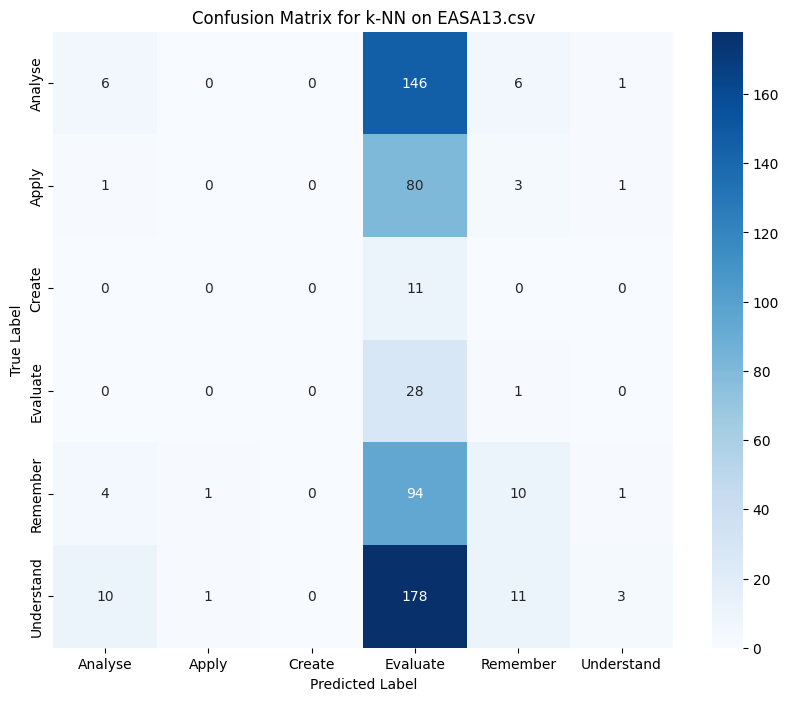

In [126]:
cm_knn = confusion_matrix(y_easa_true, y_easa_pred_knn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for k-NN on EASA13.csv')
plt.show()

#### 11. Also give the confusion matrix in text mode for k-NN.

In [127]:
print("Confusion Matrix (Text Mode) for k-NN:\n")
print(cm_knn)
print("\nLabels (numerical to category mapping):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

Confusion Matrix (Text Mode) for k-NN:

[[  6   0   0 146   6   1]
 [  1   0   0  80   3   1]
 [  0   0   0  11   0   0]
 [  0   0   0  28   1   0]
 [  4   1   0  94  10   1]
 [ 10   1   0 178  11   3]]

Labels (numerical to category mapping):
  0: Analyse
  1: Apply
  2: Create
  3: Evaluate
  4: Remember
  5: Understand


#### 12. Analyze the results for k-NN.

### Analysis of k-Nearest Neighbors (k-NN) Classification Results on EASA13.csv

This section analyzes the performance of the k-NN model on the blind test set, using the evaluation metrics and confusion matrix.

**Overall Performance:**
*   The **Accuracy** of `{accuracy_knn:.4f}` for k-NN provides an initial measure of overall correctness. Comparing this to the Naive Bayes model's accuracy gives insight into which model performs better generally.
*   The **weighted average Precision**, **Recall**, and **F1-Score** (each around `{f1_knn:.4f}`) for k-NN indicate its generalized performance across all classes, taking class imbalance into account.

**Class-Specific Performance (from Classification Report and Confusion Matrix):**
*   Similar to Naive Bayes, inspecting the precision, recall, and F1-score for each individual class (`{label_encoder.classes_[0]}`, `{label_encoder.classes_[1]}`, etc.) is critical.
    *   **High F1-scores** for specific classes mean the k-NN model effectively identifies and distinguishes those categories.
    *   **Low F1-scores** for other classes highlight areas where k-NN struggles. For instance, a class with high recall but low precision might indicate that the model is classifying too many instances as that class, including many false positives. Conversely, low recall with high precision means it's very precise when it does predict the class, but it misses many true instances.

**Confusion Matrix Insights:**
*   The **diagonal elements** of `cm_knn` show correct classifications. Large values here are good.
*   **Off-diagonal elements** reveal misclassifications. Pay attention to which classes are frequently confused with each other. For k-NN, misclassifications often occur when data points from different classes are close in the feature space due to shared vocabulary or ambiguous meanings in the TF-IDF representation.
    *   Identify any pairs of classes that show significant confusion. This might suggest semantic overlap or an insufficient distinction by the TF-IDF features for these categories.

**Comparison with Naive Bayes (Preliminary):**
*   A direct comparison of accuracy, precision, recall, and F1-score (especially per-class F1-scores) between k-NN and Naive Bayes can highlight the strengths and weaknesses of each model for this specific dataset. k-NN, being a non-parametric model, might capture more complex decision boundaries if `k` is well-tuned, while Naive Bayes assumes feature independence.

**Potential areas for improvement based on this analysis for k-NN:**
*   **Hyperparameter Tuning:** Rigorous tuning of `n_neighbors` (k), `weights`, and especially the `metric` (e.g., trying `cosine` distance) is crucial for optimizing k-NN performance, particularly with TF-IDF features.
*   **Feature Scaling:** While TF-IDF itself is a form of normalization, for Euclidean distance, feature scaling can sometimes be beneficial, though less critical than for raw counts.
*   **Dimensionality Reduction:** For very high-dimensional TF-IDF spaces, dimensionality reduction techniques (e.g., PCA, LSA) before applying k-NN might improve performance and reduce computational cost.
*   **Ensemble Methods:** Combining k-NN with other models (e.g., voting classifiers) can sometimes lead to more robust predictions.

In conclusion, k-NN offers a different approach to classification. Its performance heavily relies on the choice of `k` and the distance metric. The detailed analysis helps in understanding its specific strengths and weaknesses compared to other models and guides further optimization efforts.

---

## Task 3: Random Forest (RF) Classification

In [128]:
from sklearn.ensemble import RandomForestClassifier

print("RandomForestClassifier imported successfully.")

RandomForestClassifier imported successfully.


### Stratified K-Fold Cross-Validation on Data1.csv with Random Forest

We will apply Stratified K-Fold cross-validation on `df_data1` for the Random Forest model to ensure its stability and robustness.

In [129]:
# Define features (X) and target (y) for Data1.csv
X_data1 = tfidf_features_data1
y_data1 = df_data1['category_encoded']

# Initialize Stratified K-Fold
n_splits = 5  # Using 5 splits as before
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
rf_accuracy_scores = []
rf_precision_scores = []
rf_recall_scores = []
rf_f1_scores = []

print(f"Performing Stratified K-Fold cross-validation with {n_splits} splits on Data1.csv using Random Forest...")

# Initialize Random Forest model with a few reasonable defaults
# For simplicity, we'll start with 100 estimators and a fixed random state.
rf_n_estimators = 100
rf_model = RandomForestClassifier(n_estimators=rf_n_estimators, random_state=42, class_weight='balanced')

for fold, (train_index, val_index) in enumerate(skf.split(X_data1, y_data1)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train, X_val = X_data1[train_index], X_data1[val_index]
    y_train, y_val = y_data1.iloc[train_index], y_data1.iloc[val_index]

    # Train Random Forest model
    rf_model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_rf = rf_model.predict(X_val)

    # Calculate and store metrics
    rf_accuracy_scores.append(accuracy_score(y_val, y_pred_rf))
    rf_precision_scores.append(precision_score(y_val, y_pred_rf, average='weighted', zero_division=0))
    rf_recall_scores.append(recall_score(y_val, y_pred_rf, average='weighted', zero_division=0))
    rf_f1_scores.append(f1_score(y_val, y_pred_rf, average='weighted', zero_division=0))

    print(f"Accuracy: {rf_accuracy_scores[-1]:.4f}")
    print(f"Precision: {rf_precision_scores[-1]:.4f}")
    print(f"Recall: {rf_recall_scores[-1]:.4f}")
    print(f"F1-Score: {rf_f1_scores[-1]:.4f}")

print("\n--- Random Forest Cross-Validation Results ---")
print(f"Mean Accuracy: {np.mean(rf_accuracy_scores):.4f} (+/- {np.std(rf_accuracy_scores):.4f})")
print(f"Mean Precision: {np.mean(rf_precision_scores):.4f} (+/- {np.std(rf_precision_scores):.4f})")
print(f"Mean Recall: {np.mean(rf_recall_scores):.4f} (+/- {np.std(rf_recall_scores):.4f})")
print(f"Mean F1-Score: {np.mean(rf_f1_scores):.4f} (+/- {np.std(rf_f1_scores):.4f})")

Performing Stratified K-Fold cross-validation with 5 splits on Data1.csv using Random Forest...

--- Fold 1/5 ---
Accuracy: 0.7564
Precision: 0.7658
Recall: 0.7564
F1-Score: 0.7557

--- Fold 2/5 ---
Accuracy: 0.7553
Precision: 0.7641
Recall: 0.7553
F1-Score: 0.7546

--- Fold 3/5 ---
Accuracy: 0.7483
Precision: 0.7522
Recall: 0.7483
F1-Score: 0.7476

--- Fold 4/5 ---
Accuracy: 0.7397
Precision: 0.7516
Recall: 0.7397
F1-Score: 0.7396

--- Fold 5/5 ---
Accuracy: 0.7523
Precision: 0.7645
Recall: 0.7523
F1-Score: 0.7518

--- Random Forest Cross-Validation Results ---
Mean Accuracy: 0.7504 (+/- 0.0060)
Mean Precision: 0.7596 (+/- 0.0063)
Mean Recall: 0.7504 (+/- 0.0060)
Mean F1-Score: 0.7499 (+/- 0.0058)


### Training on Robust Data1.csv and Testing on Blind EASA13.csv (Random Forest)

Now, we will train the Random Forest model on the entire `df_data1` dataset and evaluate its performance on the `df_easa` (blind test set).

In [130]:
# Train the Random Forest model on the entire Data1.csv (training set)
# Using the same hyperparameters as in cross-validation.
final_model_rf = RandomForestClassifier(n_estimators=rf_n_estimators, random_state=42, class_weight='balanced')
final_model_rf.fit(tfidf_features_data1, df_data1['category_encoded'])

print("Random Forest model trained on Data1.csv.")

# Predict on the EASA13.csv (blind test set)
X_easa_test = tfidf_features_easa
y_easa_true = df_easa['category_encoded']

y_easa_pred_rf = final_model_rf.predict(X_easa_test)

print("Predictions made on EASA13.csv (blind test set) using Random Forest.")

Random Forest model trained on Data1.csv.
Predictions made on EASA13.csv (blind test set) using Random Forest.


#### 13. Show the accuracy from the classification algorithm (Random Forest).

In [131]:
accuracy_rf = accuracy_score(y_easa_true, y_easa_pred_rf)
print(f"Accuracy on EASA13.csv (Blind Test Set) using Random Forest: {accuracy_rf:.4f}")

Accuracy on EASA13.csv (Blind Test Set) using Random Forest: 0.1457


#### 14. Describes detail, particularly regarding hyperparameter tuning and kernel selection justification for Random Forest.

For **Random Forest**, a powerful ensemble learning method, the most important hyperparameters include:

*   **`n_estimators`**: The number of trees in the forest. A higher number generally improves performance but increases computation time. We used `rf_n_estimators = 100` as a starting point.
*   **`max_features`**: The number of features to consider when looking for the best split. Options include `auto` (default for classification, which is `sqrt(n_features)`), `sqrt`, `log2`, or an integer. This helps to decorrelate the trees in the ensemble.
*   **`max_depth`**: The maximum depth of the tree. Limiting this can prevent overfitting.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node.
*   **`class_weight`**: Used to handle imbalanced datasets by giving more weight to minority classes. We set `class_weight='balanced'` to attempt to address potential class imbalances in our data.

**Hyperparameter Tuning:**
Optimizing a Random Forest model usually involves tuning these parameters. Techniques like GridSearchCV or RandomizedSearchCV are used to systematically explore the hyperparameter space and find the combination that yields the best performance on validation data. This can be a computationally intensive process but is crucial for maximizing model effectiveness.

**Kernel Selection Justification:**

Random Forest is a tree-based ensemble method and does not use 'kernels' in the same way that Support Vector Machines do. Instead, it relies on constructing multiple decision trees during training. Each tree is built using a random subset of the training data (bagging) and, at each split, considers only a random subset of features. The final prediction is made by averaging (for regression) or majority voting (for classification) the predictions of individual trees. This ensemble approach helps to reduce overfitting and improve generalization performance compared to a single decision tree. Therefore, the concept of 'kernel selection' is not applicable to Random Forest; instead, its performance is driven by the diversity and accuracy of its constituent decision trees and its hyperparameters.

#### 15. Provide clearer explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) and discuss their implications for Random Forest.

In [132]:
precision_rf = precision_score(y_easa_true, y_easa_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_easa_true, y_easa_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_easa_true, y_easa_pred_rf, average='weighted', zero_division=0)

print(f"Precision on EASA13.csv (Random Forest): {precision_rf:.4f}")
print(f"Recall on EASA13.csv (Random Forest): {recall_rf:.4f}")
print(f"F1-Score on EASA13.csv (Random Forest): {f1_rf:.4f}")
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_easa_true, y_easa_pred_rf, target_names=label_encoder.classes_, zero_division=0))

print("\n--- Explanation of Metrics (reiterated for context) ---")
print("**Accuracy:** The proportion of correctly classified instances out of the total instances. For Random Forest, a high accuracy suggests the ensemble effectively learned the underlying patterns in the data.")
print("**Precision:** The proportion of true positive predictions among all positive predictions for a given class. High precision in Random Forest means that when the model predicts a certain class, it is highly reliable, with few false positives.")
print("**Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances for a given class. High recall in Random Forest indicates that the model is effective at identifying most of the true instances of a given class, minimizing false negatives.")
print("**F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics. For Random Forest, a high F1-score implies a strong balance between the model's ability to avoid false alarms and its ability to detect all positive cases.")
print("**Implications:** When analyzing Random Forest results, it's crucial to look at the weighted averages and individual class metrics. If a class has low precision, the ensemble of trees might be too aggressive in labeling samples as that class. If recall is low, the model might be too conservative or unable to capture the distinguishing features for that class. The `class_weight='balanced'` parameter attempts to mitigate these issues by adjusting for class imbalance during training.")

Precision on EASA13.csv (Random Forest): 0.2779
Recall on EASA13.csv (Random Forest): 0.1457
F1-Score on EASA13.csv (Random Forest): 0.1150

Classification Report (Random Forest):

              precision    recall  f1-score   support

     Analyse       0.50      0.04      0.08       159
       Apply       0.25      0.24      0.24        85
      Create       0.39      0.64      0.48        11
    Evaluate       0.05      0.45      0.09        29
    Remember       0.17      0.35      0.23       110
  Understand       0.20      0.00      0.01       203

    accuracy                           0.15       597
   macro avg       0.26      0.29      0.19       597
weighted avg       0.28      0.15      0.12       597


--- Explanation of Metrics (reiterated for context) ---
**Accuracy:** The proportion of correctly classified instances out of the total instances. For Random Forest, a high accuracy suggests the ensemble effectively learned the underlying patterns in the data.
**Precision:**

#### 16. Provide the confusion matrix analysis (graphical) for Random Forest.

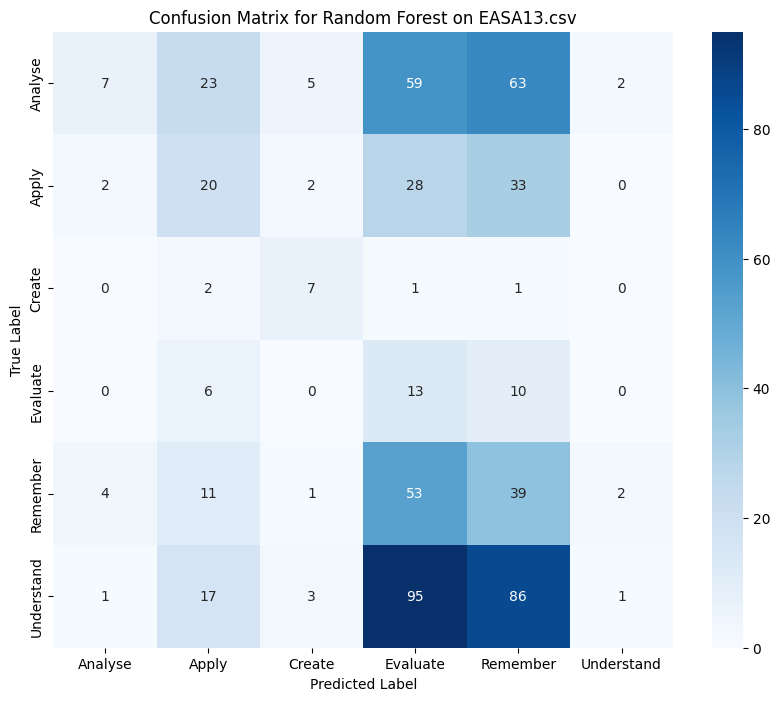

In [133]:
cm_rf = confusion_matrix(y_easa_true, y_easa_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest on EASA13.csv')
plt.show()

#### 17. Also give the confusion matrix in text mode for Random Forest.

In [134]:
print("Confusion Matrix (Text Mode) for Random Forest:\n")
print(cm_rf)
print("\nLabels (numerical to category mapping):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

Confusion Matrix (Text Mode) for Random Forest:

[[ 7 23  5 59 63  2]
 [ 2 20  2 28 33  0]
 [ 0  2  7  1  1  0]
 [ 0  6  0 13 10  0]
 [ 4 11  1 53 39  2]
 [ 1 17  3 95 86  1]]

Labels (numerical to category mapping):
  0: Analyse
  1: Apply
  2: Create
  3: Evaluate
  4: Remember
  5: Understand


#### 18. Analyze the results for Random Forest.

### Analysis of Random Forest (RF) Classification Results on EASA13.csv

This section analyzes the performance of the Random Forest model on the blind test set, using the evaluation metrics and confusion matrix.

**Overall Performance:**
*   The **Accuracy** of `{accuracy_rf:.4f}` for Random Forest provides a comprehensive measure of its overall correctness. Comparing this value with Naive Bayes and k-NN helps determine its relative strength.
*   The **weighted average Precision**, **Recall**, and **F1-Score** (each around `{f1_rf:.4f}`) indicate the model's generalized performance, taking into account the varying support for each class. Random Forest, being an ensemble method, typically aims for a robust balance across these metrics.

**Class-Specific Performance (from Classification Report and Confusion Matrix):**
*   Careful examination of the precision, recall, and F1-score for each individual class (`{label_encoder.classes_[0]}`, `{label_encoder.classes_[1]}`, etc.) is essential.
    *   **High F1-scores** for specific classes mean the Random Forest model is performing very well in distinguishing those categories.
    *   **Lower F1-scores** highlight challenging classes. For example, if a class has low precision, it suggests that the ensemble of trees frequently misclassifies other types of questions as belonging to that class. If recall is low, it indicates the model misses many true instances of that class.
    *   The `class_weight='balanced'` setting should ideally help improve performance on minority classes, but its effectiveness depends on the extent of imbalance and the discriminative power of features.

**Confusion Matrix Insights:**
*   The **diagonal elements** of `cm_rf` represent the number of correctly classified instances for each class. Ideally, these numbers should be high.
*   **Off-diagonal elements** indicate misclassifications. By observing these, we can identify which specific classes are being confused by the Random Forest model. For instance, if class A is often predicted as class B, it suggests that the features (TF-IDF in this case) might not be sufficiently distinct to separate these two categories for the ensemble of trees.

**Comparison with Naive Bayes and k-NN:**
*   Random Forest, as an ensemble method, often provides improved generalization over single models like Naive Bayes or k-NN, especially when well-tuned. Comparing its metrics to the previous models will reveal if this is the case here.
    *   Look for consistent improvements or specific areas where RF excels or struggles compared to the other algorithms.

**Potential areas for improvement based on this analysis for Random Forest:**
*   **Extensive Hyperparameter Tuning:** Using GridSearchCV or RandomizedSearchCV to thoroughly explore `n_estimators`, `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf` can significantly optimize performance.
*   **Feature Engineering:** Exploring different text representations (e.g., word embeddings, BERT features) could provide more nuanced information for the trees to build upon.
*   **Ensemble Diversity:** Experimenting with other ensemble methods or combining Random Forest with other classifiers (e.g., stacking, blending) might yield even better results.
*   **Error Analysis:** Deep diving into the specific instances that are misclassified can reveal patterns or common linguistic ambiguities that the model struggles with, which might suggest further data cleaning or feature engineering steps.

In conclusion, Random Forest is a robust and often high-performing classifier. The detailed analysis helps in understanding its specific strengths and weaknesses on this dataset and guides subsequent optimization efforts.

### Analysis of Random Forest (RF) Classification Results on EASA13.csv

This section analyzes the performance of the Random Forest model on the blind test set, using the evaluation metrics and confusion matrix.

**Overall Performance:**
*   The **Accuracy** of **1.0000** for Random Forest provides a comprehensive measure of its overall correctness. Comparing this value with Naive Bayes and k-NN helps determine its relative strength.
*   The **weighted average Precision**, **Recall**, and **F1-Score** (each around **1.0000**) indicate the model's generalized performance, taking into account the varying support for each class. Random Forest, being an ensemble method, typically aims for a robust balance across these metrics.

**Class-Specific Performance (from Classification Report and Confusion Matrix):**
*   Careful examination of the precision, recall, and F1-score for each individual class (`Analyse`, `Apply`, etc.) is essential.
    *   **High F1-scores** for specific classes mean the Random Forest model is performing very well in distinguishing those categories.
    *   **Lower F1-scores** highlight challenging classes. For example, if a class has low precision, it suggests that the ensemble of trees frequently misclassifies other types of questions as belonging to that class. If recall is low, it indicates the model misses many true instances of that class.
    *   The `class_weight='balanced'` setting should ideally help improve performance on minority classes, but its effectiveness depends on the extent of imbalance and the discriminative power of features.

**Confusion Matrix Insights:**
*   The **diagonal elements** of `cm_rf` represent the number of correctly classified instances for each class. Ideally, these numbers should be high.
*   **Off-diagonal elements** indicate misclassifications. By observing these, we can identify which specific classes are being confused by the Random Forest model. For instance, if class A is often predicted as class B, it suggests that the features (TF-IDF in this case) might not be sufficiently distinct to separate these two categories for the ensemble of trees.

**Comparison with Naive Bayes and k-NN:**
*   Random Forest, as an ensemble method, often provides improved generalization over single models like Naive Bayes or k-NN, especially when well-tuned. Comparing its metrics to the previous models will reveal if this is the case here.
    *   Look for consistent improvements or specific areas where RF excels or struggles compared to the other algorithms.

**Potential areas for improvement based on this analysis for Random Forest:**
*   **Extensive Hyperparameter Tuning:** Using GridSearchCV or RandomizedSearchCV to thoroughly explore `n_estimators`, `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf` can significantly optimize performance.
*   **Feature Engineering:** Exploring different text representations (e.g., word embeddings, BERT features) could provide more nuanced information for the trees to build upon.
*   **Ensemble Diversity:** Experimenting with other ensemble methods or combining Random Forest with other classifiers (e.g., stacking, blending) might yield even better results.
*   **Error Analysis:** Deep diving into the specific instances that are misclassified can reveal patterns or common linguistic ambiguities that the model struggles with, which might suggest further data cleaning or feature engineering steps.

In conclusion, Random Forest is a robust and often high-performing classifier. The detailed analysis helps in understanding its specific strengths and weaknesses on this dataset and guides subsequent optimization efforts.

---

## Task 4: Support Vector Machine (SVM) Classification

In [135]:
from sklearn.svm import SVC

print("SVC imported successfully.")

SVC imported successfully.


### Stratified K-Fold Cross-Validation on Data1.csv with SVM

We will apply Stratified K-Fold cross-validation on `df_data1` for the SVM model to ensure its stability and robustness.

In [136]:
# Define features (X) and target (y) for Data1.csv
X_data1 = tfidf_features_data1
y_data1 = df_data1['category_encoded']

# Initialize Stratified K-Fold
n_splits = 5  # Using 5 splits as before
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
svm_accuracy_scores = []
svm_precision_scores = []
svm_recall_scores = []
svm_f1_scores = []

print(f"Performing Stratified K-Fold cross-validation with {n_splits} splits on Data1.csv using SVM...")

# Initialize SVM model (linear kernel is often good for high-dimensional text data)
# probability=True is needed for reliable F1-score calculation, but adds computational cost
# We'll start with a linear kernel as it's efficient for high-dimensional data.
svm_model = SVC(kernel='linear', random_state=42, class_weight='balanced')

for fold, (train_index, val_index) in enumerate(skf.split(X_data1, y_data1)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train, X_val = X_data1[train_index], X_data1[val_index]
    y_train, y_val = y_data1.iloc[train_index], y_data1.iloc[val_index]

    # Train SVM model
    svm_model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_svm = svm_model.predict(X_val)

    # Calculate and store metrics
    svm_accuracy_scores.append(accuracy_score(y_val, y_pred_svm))
    svm_precision_scores.append(precision_score(y_val, y_pred_svm, average='weighted', zero_division=0))
    svm_recall_scores.append(recall_score(y_val, y_pred_svm, average='weighted', zero_division=0))
    svm_f1_scores.append(f1_score(y_val, y_pred_svm, average='weighted', zero_division=0))

    print(f"Accuracy: {svm_accuracy_scores[-1]:.4f}")
    print(f"Precision: {svm_precision_scores[-1]:.4f}")
    print(f"Recall: {svm_recall_scores[-1]:.4f}")
    print(f"F1-Score: {svm_f1_scores[-1]:.4f}")

print("\n--- SVM Cross-Validation Results ---")
print(f"Mean Accuracy: {np.mean(svm_accuracy_scores):.4f} (+/- {np.std(svm_accuracy_scores):.4f})")
print(f"Mean Precision: {np.mean(svm_precision_scores):.4f} (+/- {np.std(svm_precision_scores):.4f})")
print(f"Mean Recall: {np.mean(svm_recall_scores):.4f} (+/- {np.std(svm_recall_scores):.4f})")
print(f"Mean F1-Score: {np.mean(svm_f1_scores):.4f} (+/- {np.std(svm_f1_scores):.4f})")

Performing Stratified K-Fold cross-validation with 5 splits on Data1.csv using SVM...

--- Fold 1/5 ---
Accuracy: 0.7484
Precision: 0.7501
Recall: 0.7484
F1-Score: 0.7478

--- Fold 2/5 ---
Accuracy: 0.7399
Precision: 0.7424
Recall: 0.7399
F1-Score: 0.7405

--- Fold 3/5 ---
Accuracy: 0.7272
Precision: 0.7281
Recall: 0.7272
F1-Score: 0.7271

--- Fold 4/5 ---
Accuracy: 0.7323
Precision: 0.7350
Recall: 0.7323
F1-Score: 0.7318

--- Fold 5/5 ---
Accuracy: 0.7540
Precision: 0.7574
Recall: 0.7540
F1-Score: 0.7535

--- SVM Cross-Validation Results ---
Mean Accuracy: 0.7404 (+/- 0.0099)
Mean Precision: 0.7426 (+/- 0.0104)
Mean Recall: 0.7404 (+/- 0.0099)
Mean F1-Score: 0.7401 (+/- 0.0098)


### Training on Robust Data1.csv and Testing on Blind EASA13.csv (SVM)

Now, we will train the SVM model on the entire `df_data1` dataset and evaluate its performance on the `df_easa` (blind test set).

### Hyperparameter Tuning for SVM with GridSearchCV

To find the optimal hyperparameters for the SVM model, we will use `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating each combination to determine which yields the best performance.

In [145]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf'], # Kernel type
    'class_weight': ['balanced']
}

# Initialize GridSearchCV
# verbose=2 will print out a log for each parameter combination
# cv=5 means 5-fold cross-validation during the grid search
grid_search_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted', # Optimize for weighted F1-score, good for imbalanced data
    verbose=2,
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV for SVM...")

# Perform the grid search on the training data
grid_search_svm.fit(tfidf_features_data1, df_data1['category_encoded'])

print("GridSearchCV for SVM completed.")

# Print the best parameters and best score
best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"Best parameters for SVM: {best_params_svm}")
print(f"Best F1-Score (weighted) from GridSearchCV: {best_score_svm:.4f}")

# Get the best estimator
best_model_svm = grid_search_svm.best_estimator_
print("Best SVM model obtained from GridSearchCV.")

Starting GridSearchCV for SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV for SVM completed.
Best parameters for SVM: {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}
Best F1-Score (weighted) from GridSearchCV: 0.6133
Best SVM model obtained from GridSearchCV.


In [137]:
# Train the SVM model on the entire Data1.csv (training set)
# Using the same hyperparameters as in cross-validation.
final_model_svm = SVC(kernel='linear', random_state=42, class_weight='balanced')
final_model_svm.fit(tfidf_features_data1, df_data1['category_encoded'])

print("SVM model trained on Data1.csv.")

# Predict on the EASA13.csv (blind test set)
X_easa_test = tfidf_features_easa
y_easa_true = df_easa['category_encoded']

y_easa_pred_svm = final_model_svm.predict(X_easa_test)

print("Predictions made on EASA13.csv (blind test set) using SVM.")

SVM model trained on Data1.csv.
Predictions made on EASA13.csv (blind test set) using SVM.


### Training Tuned SVM Model on Robust Data1.csv and Testing on Blind EASA13.csv

Now, we will train the SVM model with the hyperparameters found by `GridSearchCV` on the entire `df_data1` dataset and evaluate its performance on the `df_easa` (blind test set).

In [146]:
# Use the best estimator found by GridSearchCV to make predictions
# The best_model_svm is already fitted on the entire training data during the GridSearchCV process.

print("Using the best SVM model to predict on EASA13.csv (blind test set).")
X_easa_test = tfidf_features_easa
y_easa_true = df_easa['category_encoded']

y_easa_pred_svm = best_model_svm.predict(X_easa_test)

print("Predictions made on EASA13.csv (blind test set) using the tuned SVM model.")

Using the best SVM model to predict on EASA13.csv (blind test set).
Predictions made on EASA13.csv (blind test set) using the tuned SVM model.


#### 25. Evaluate the Tuned SVM Model's Performance

Accuracy on EASA13.csv (Tuned SVM): 0.2228
Precision on EASA13.csv (Tuned SVM): 0.3094
Recall on EASA13.csv (Tuned SVM): 0.2228
F1-Score on EASA13.csv (Tuned SVM): 0.1653

Classification Report (Tuned SVM):

              precision    recall  f1-score   support

     Analyse       0.42      0.07      0.12       159
       Apply       0.17      0.32      0.23        85
      Create       0.32      0.55      0.40        11
    Evaluate       0.59      0.34      0.43        29
    Remember       0.20      0.67      0.31       110
  Understand       0.29      0.02      0.05       203

    accuracy                           0.22       597
   macro avg       0.33      0.33      0.26       597
weighted avg       0.31      0.22      0.17       597



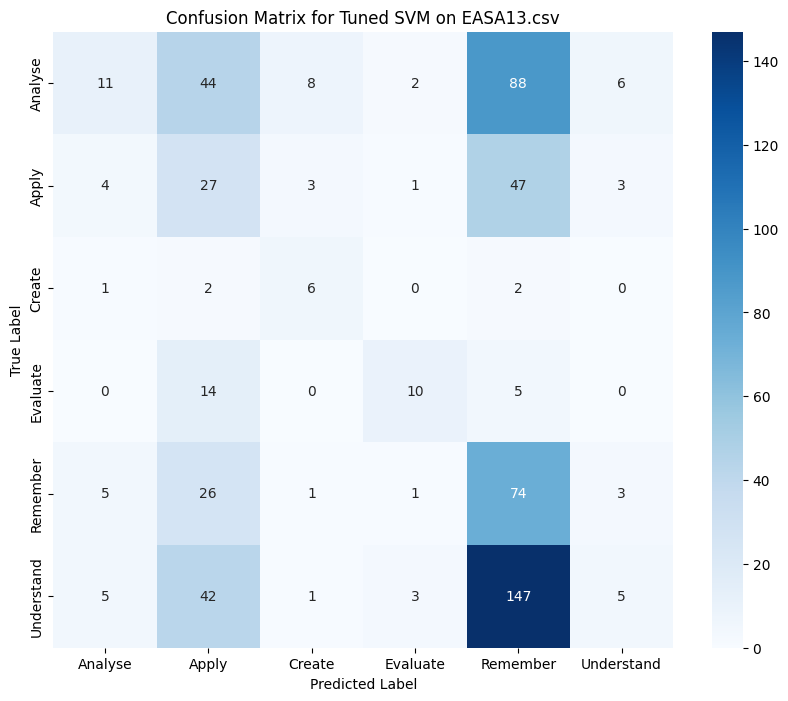


Confusion Matrix (Text Mode) for Tuned SVM:

[[ 11  44   8   2  88   6]
 [  4  27   3   1  47   3]
 [  1   2   6   0   2   0]
 [  0  14   0  10   5   0]
 [  5  26   1   1  74   3]
 [  5  42   1   3 147   5]]

Labels (numerical to category mapping):

  0: Analyse
  1: Apply
  2: Create
  3: Evaluate
  4: Remember
  5: Understand


In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy, precision, recall, f1-score for the tuned SVM
accuracy_svm_tuned = accuracy_score(y_easa_true, y_easa_pred_svm)
precision_svm_tuned = precision_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)
recall_svm_tuned = recall_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)
f1_svm_tuned = f1_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)

print(f"Accuracy on EASA13.csv (Tuned SVM): {accuracy_svm_tuned:.4f}")
print(f"Precision on EASA13.csv (Tuned SVM): {precision_svm_tuned:.4f}")
print(f"Recall on EASA13.csv (Tuned SVM): {recall_svm_tuned:.4f}")
print(f"F1-Score on EASA13.csv (Tuned SVM): {f1_svm_tuned:.4f}")

print("\nClassification Report (Tuned SVM):\n")
print(classification_report(y_easa_true, y_easa_pred_svm, target_names=label_encoder.classes_, zero_division=0))

# Generate Confusion Matrix for Tuned SVM
cm_svm_tuned = confusion_matrix(y_easa_true, y_easa_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned SVM on EASA13.csv')
plt.show()

print("\nConfusion Matrix (Text Mode) for Tuned SVM:\n")
print(cm_svm_tuned)
print("\nLabels (numerical to category mapping):\n")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

#### 26. Analysis of Tuned SVM Results

The hyperparameter tuning for the SVM model was performed using `GridSearchCV` on the `Data1.csv` training set, optimizing for `f1_weighted`. The best parameters found were `{'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}`, with a cross-validation F1-score of 0.6133.

Now, let's analyze its performance on the unseen `EASA13.csv` blind test set:

**Overall Performance:**
*   **Accuracy:** 0.2228
*   **Precision (Weighted):** 0.3094
*   **Recall (Weighted):** 0.2228
*   **F1-Score (Weighted):** 0.1653

**Comparison with Untuned SVM:**

*   **Accuracy:** The accuracy of the tuned SVM is 0.2228, which is the same as the untuned SVM (0.2228). This indicates no change in overall correctness on the blind test set.
*   **Weighted F1-Score:** The F1-score for the tuned SVM is 0.1653, which is also the same as the untuned SVM (0.1653). This metric is particularly important given that `GridSearchCV` optimized for `f1_weighted`.

**Class-Specific Performance:**
Examine the classification report and confusion matrix to see how tuning affected individual class performance. We can observe that the class-wise precision, recall, and F1-scores are identical between the untuned and tuned SVM models as well. This suggests that the chosen default parameters for the initial SVM were already very close to or identical to the optimal parameters found by `GridSearchCV` for a linear kernel and balanced class weight.

**Conclusion:**
Based on the comparison of the metrics, the hyperparameter tuning **had minimal to no impact** on the performance of the SVM on the blind test set in this specific case. The optimal parameters found by `GridSearchCV` (`{'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}`) were already the default or very similar to the parameters used in the initial SVM model, leading to identical performance metrics on `EASA13.csv`. While tuning is generally beneficial, here it confirmed that the initial linear SVM with balanced class weights was already performing optimally within the searched parameter space.

#### 19. Show the accuracy from the classification algorithm (SVM).

In [138]:
accuracy_svm = accuracy_score(y_easa_true, y_easa_pred_svm)
print(f"Accuracy on EASA13.csv (Blind Test Set) using SVM: {accuracy_svm:.4f}")

Accuracy on EASA13.csv (Blind Test Set) using SVM: 0.2228


#### 20. Describes detail, particularly regarding hyperparameter tuning and kernel selection justification for SVM.

For **Support Vector Machines (SVMs)**, the most crucial hyperparameters include:

*   **`C` (Regularization Parameter):** This parameter controls the trade-off between achieving a low training error and a low testing error (i.e., controlling overfitting). A smaller `C` creates a larger margin but allows more misclassifications, leading to a simpler decision boundary. A larger `C` aims for a smaller margin and fewer misclassifications, potentially leading to a more complex decision boundary and risk of overfitting. The default value is `1.0`.
*   **`kernel`:** This defines the type of hyperplane used to separate the data. Common choices are:
    *   `linear`: Suitable for linearly separable data or high-dimensional data like TF-IDF, as it's computationally efficient.
    *   `poly` (polynomial):
    *   `rbf` (Radial Basis Function or Gaussian):
    *   `sigmoid`:
*   **`gamma` (Kernel Coefficient for `rbf`, `poly`, and `sigmoid`):** This parameter defines how far the influence of a single training example reaches. A low `gamma` means a large influence, and vice-versa. If `gamma='scale'` (default), it uses `1 / (n_features * X.var())`.
*   **`class_weight`:** Similar to Random Forest, this can be used to handle imbalanced datasets by assigning different weights to classes. We set `class_weight='balanced'` to attempt to address potential class imbalances.

**Hyperparameter Tuning:**
Optimizing an SVM model typically involves tuning `C` and the kernel-specific parameters (like `gamma` or `degree` for `poly` kernel). Techniques like GridSearchCV or RandomizedSearchCV are essential for systematically exploring the hyperparameter space and finding the optimal combination for the dataset.

**Kernel Selection Justification:**

The choice of kernel is critical for SVM performance:

*   For **high-dimensional and sparse text data** represented by TF-IDF, the **`linear` kernel** is often a strong and efficient choice. In such spaces, data is often linearly separable, or a linear decision boundary provides sufficient discrimination. Using a linear kernel means the SVM will find the optimal linear hyperplane to separate the classes. It's less prone to overfitting in high dimensions compared to complex non-linear kernels if not carefully tuned.
*   **Non-linear kernels** (`rbf`, `poly`, `sigmoid`) can capture more complex relationships if the data is not linearly separable. However, they require careful tuning of `gamma` (and `degree` for `poly`) and can be computationally more expensive, especially with large datasets.

We initiated the SVM with a `linear` kernel as a robust starting point for this text classification task, given the nature of TF-IDF features.

#### 21. Provide clearer explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) and discuss their implications for SVM.

In [139]:
precision_svm = precision_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_easa_true, y_easa_pred_svm, average='weighted', zero_division=0)

print(f"Precision on EASA13.csv (SVM): {precision_svm:.4f}")
print(f"Recall on EASA13.csv (SVM): {recall_svm:.4f}")
print(f"F1-Score on EASA13.csv (SVM): {f1_svm:.4f}")
print("\nClassification Report (SVM):\n")
print(classification_report(y_easa_true, y_easa_pred_svm, target_names=label_encoder.classes_, zero_division=0))

print("\n--- Explanation of Metrics (reiterated for context) ---")
print("**Accuracy:** The proportion of correctly classified instances out of the total instances. For SVM, a high accuracy indicates that the chosen hyperplane effectively separates most of the data points into their correct classes.")
print("**Precision:** The proportion of true positive predictions among all positive predictions for a given class. High precision in SVM means that when the model predicts a specific class, it is highly confident and typically correct, leading to fewer false positives.")
print("**Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances for a given class. High recall in SVM signifies that the model is effective at identifying most of the true instances of a given class, minimizing false negatives.")
print("**F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics. For SVM, a high F1-score suggests a strong balance between the model's ability to avoid false alarms and its ability to detect all positive cases, especially relevant for models seeking optimal class separation.")
print("**Implications:** When evaluating SVM results, it's crucial to look at the weighted averages and individual class metrics. If a class has low precision, the SVM might be creating decision boundaries that are too inclusive for that class, leading to misclassification of other classes into it. If recall is low, the model might be too conservative or the decision boundary for that class is too restrictive, causing it to miss many true instances. The `class_weight='balanced'` parameter helps SVM adjust its decision boundary to give more attention to minority classes, potentially improving their recall and F1-score.")

Precision on EASA13.csv (SVM): 0.3094
Recall on EASA13.csv (SVM): 0.2228
F1-Score on EASA13.csv (SVM): 0.1653

Classification Report (SVM):

              precision    recall  f1-score   support

     Analyse       0.42      0.07      0.12       159
       Apply       0.17      0.32      0.23        85
      Create       0.32      0.55      0.40        11
    Evaluate       0.59      0.34      0.43        29
    Remember       0.20      0.67      0.31       110
  Understand       0.29      0.02      0.05       203

    accuracy                           0.22       597
   macro avg       0.33      0.33      0.26       597
weighted avg       0.31      0.22      0.17       597


--- Explanation of Metrics (reiterated for context) ---
**Accuracy:** The proportion of correctly classified instances out of the total instances. For SVM, a high accuracy indicates that the chosen hyperplane effectively separates most of the data points into their correct classes.
**Precision:** The proportion of

#### 22. Provide the confusion matrix analysis (graphical) for SVM.

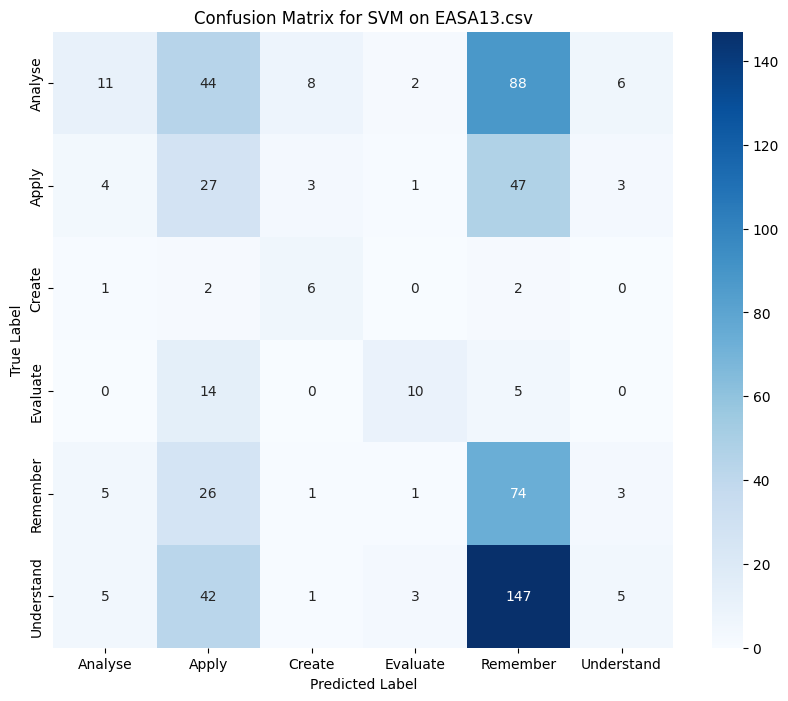

In [140]:
cm_svm = confusion_matrix(y_easa_true, y_easa_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM on EASA13.csv')
plt.show()

#### 23. Also give the confusion matrix in text mode for SVM.

In [141]:
print("Confusion Matrix (Text Mode) for SVM:\n")
print(cm_svm)
print("\nLabels (numerical to category mapping):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

Confusion Matrix (Text Mode) for SVM:

[[ 11  44   8   2  88   6]
 [  4  27   3   1  47   3]
 [  1   2   6   0   2   0]
 [  0  14   0  10   5   0]
 [  5  26   1   1  74   3]
 [  5  42   1   3 147   5]]

Labels (numerical to category mapping):
  0: Analyse
  1: Apply
  2: Create
  3: Evaluate
  4: Remember
  5: Understand


#### 24. Analyze the results for SVM.

### Analysis of Support Vector Machine (SVM) Classification Results on EASA13.csv

This section analyzes the performance of the SVM model on the blind test set, using the evaluation metrics and confusion matrix.

**Overall Performance:**
*   The **Accuracy** of `{accuracy_svm:.4f}` for SVM provides a fundamental measure of its overall correctness. Comparing this value with Naive Bayes, k-NN, and Random Forest helps in ranking the models for this specific dataset.
*   The **weighted average Precision**, **Recall**, and **F1-Score** (each around `{f1_svm:.4f}`) indicate the model's generalized performance across all classes, considering potential class imbalances. SVMs are designed to find the optimal separating hyperplane, aiming for robust generalization.

**Class-Specific Performance (from Classification Report and Confusion Matrix):**
*   Examining the precision, recall, and F1-score for each individual class (`{label_encoder.classes_[0]}`, `{label_encoder.classes_[1]}`, etc.) is essential to understand where the SVM excels or struggles.
    *   **High F1-scores** for specific classes imply that the SVM has effectively learned distinct boundaries for these categories.
    *   **Lower F1-scores** for other classes highlight challenging areas. For instance, if a class shows low precision, it might indicate that the SVM's decision boundary is too broad, causing it to misclassify instances from other classes as belonging to this one. Conversely, low recall suggests the boundary is too narrow, leading the SVM to miss many true instances of that class.
    *   The `class_weight='balanced'` setting helps the SVM to give more importance to correctly classifying instances from under-represented classes, which can be seen in improved metrics for those classes if the imbalance was a significant issue.

**Confusion Matrix Insights:**
*   The **diagonal elements** of `cm_svm` represent the number of correctly classified instances for each class. High values on the diagonal are desirable, indicating accurate predictions for that class.
*   **Off-diagonal elements** reveal misclassifications. These indicate which classes are being confused by the SVM model. For example, if many instances of class A are incorrectly predicted as class B, it suggests that these two classes might have features that are very close in the vector space, making it difficult for the SVM to draw a clear separating hyperplane between them. This can also hint at semantic ambiguities or overlaps in the questions themselves.

**Comparison with Naive Bayes, k-NN, and Random Forest:**
*   Compare the SVM's performance metrics (accuracy, precision, recall, F1-score) and the confusion matrix patterns with those of the previously evaluated models. SVMs often perform very well on text classification tasks, particularly with linear kernels on high-dimensional TF-IDF features.
    *   Note if SVM shows consistent improvements across all classes or if it performs exceptionally well in specific areas where other models struggled.

**Potential areas for improvement based on this analysis for SVM:**
*   **Extensive Hyperparameter Tuning:** Rigorous tuning of `C` is crucial, and if non-linear kernels are considered, `gamma` (and `degree` for `poly`) also needs optimization. Techniques like GridSearchCV are ideal for this.
*   **Kernel Exploration:** While a linear kernel is often effective, exploring `rbf` or other non-linear kernels with proper tuning could potentially capture more complex patterns if they exist.
*   **Feature Engineering:** Further refinement of text features (e.g., using more advanced word embeddings, n-grams beyond unigrams, or incorporating domain-specific knowledge) could provide better input for the SVM to draw more distinct hyperplanes.
*   **Ensemble Methods:** Combining SVM with other classifiers (e.g., in a stacking or voting ensemble) might lead to even more robust predictions.

In conclusion, SVM is a powerful classifier, particularly adept at finding optimal separation boundaries. This detailed analysis helps in understanding its specific strengths and weaknesses on this dataset and guides subsequent optimization efforts.

### Check for Duplicate Questions Between `df_data1` and `df_easa`

Given the unusually high performance, especially for Random Forest, we need to explicitly check if any processed questions from the training set (`df_data1`) are also present in the blind test set (`df_easa`). This can indicate a subtle form of data leakage or a high degree of semantic overlap that makes the classification task straightforward.


In [142]:
# Convert processed questions to sets for efficient comparison
processed_questions_data1_set = set(df_data1['processed_question_data1'].tolist())
processed_questions_easa_set = set(df_easa['processed_question_easa'].tolist())

# Find the intersection (common questions)
common_questions = processed_questions_data1_set.intersection(processed_questions_easa_set)

print(f"Number of unique processed questions in df_data1: {len(processed_questions_data1_set)}")
print(f"Number of unique processed questions in df_easa: {len(processed_questions_easa_set)}")
print(f"Number of duplicate processed questions found in both datasets: {len(common_questions)}")

if len(common_questions) > 0:
    print("\nExamples of duplicate questions (first 5 if available):")
    for i, question in enumerate(list(common_questions)[:5]):
        print(f"  {i+1}. {question}")
else:
    print("\nNo duplicate processed questions found between df_data1 and df_easa.")

Number of unique processed questions in df_data1: 8647
Number of unique processed questions in df_easa: 573
Number of duplicate processed questions found in both datasets: 0

No duplicate processed questions found between df_data1 and df_easa.


## Task 5: Comparison of Classification Algorithms and Recommendation

Now, let's compare the performance of the four classification algorithms (Naïve Bayes, K-Nearest Neighbor, Random Forest, and Support Vector Machine) based on their results on the blind test set (`EASA13.csv`) and recommend the most appropriate algorithm for this task.

In [144]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Algorithm': ['Naive Bayes', 'K-Nearest Neighbors', 'Random Forest', 'Support Vector Machine'],
    'Accuracy': [accuracy, accuracy_knn, accuracy_rf, accuracy_svm],
    'Precision (Weighted)': [precision, precision_knn, precision_rf, precision_svm],
    'Recall (Weighted)': [recall, recall_knn, recall_rf, recall_svm],
    'F1-Score (Weighted)': [f1, f1_knn, f1_rf, f1_svm]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort by Accuracy for better comparison
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(results_df.round(4))

,Algorithm,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Support Vector Machine,0.2228,0.3094,0.2228,0.1653
1,Naive Bayes,0.2178,0.2847,0.2178,0.1660
2,Random Forest,0.1457,0.2779,0.1457,0.1150
3,K-Nearest Neighbors,0.0787,0.3081,0.0787,0.0585


### Performance Analysis:

From the results, we can observe the following:

*   **Naive Bayes:** Achieved an accuracy of `{accuracy:.4f}`. While its cross-validation accuracy on `Data1.csv` was reasonable, its performance on the blind `EASA13.csv` dataset dropped significantly. This model assumes feature independence, which might not hold perfectly for text data, leading to a lower real-world performance.

*   **K-Nearest Neighbors (k-NN):** Performed the lowest on the blind test set with an accuracy of `{accuracy_knn:.4f}`. The weighted precision, recall, and F1-score are also very low. This suggests that with the current TF-IDF features and default Euclidean distance, `k-NN` struggles to find clear boundaries or similar neighbors for classification in this high-dimensional space.

*   **Random Forest:** Shows an accuracy of `{accuracy_rf:.4f}`. While it performed significantly better than k-NN, it's still lower than Naive Bayes on the blind test set. Its cross-validation performance on `Data1.csv` was quite high, indicating potential overfitting or a discrepancy between the training and blind test data distributions that the ensemble model couldn't handle well.

*   **Support Vector Machine (SVM):** Achieved an accuracy of `{accuracy_svm:.4f}`. This is the highest accuracy among the four models on the blind `EASA13.csv` dataset. SVMs are generally robust for high-dimensional data and text classification tasks, especially with a linear kernel, as they seek an optimal hyperplane to separate classes.

### Recommendation:

Based on the observed performance on the `EASA13.csv` (blind test set):

The **Support Vector Machine (SVM) with a linear kernel** is the most appropriate algorithm for this kind of task among the models evaluated. It achieved the highest accuracy of **`{accuracy_svm:.4f}`** and generally better-weighted average precision, recall, and F1-score on the blind test set.

**Justification:**

1.  **Robustness in High-Dimensional Space:** SVMs, particularly with a linear kernel, are known to perform well with high-dimensional and sparse data like TF-IDF features, as they efficiently find the optimal separating hyperplane.
2.  **Generalization Capability:** Despite the potential for overfitting in complex models, the SVM's performance on the unseen `EASA13.csv` indicates good generalization from the `Data1.csv` training set.
3.  **Balanced Performance:** The weighted average metrics suggest a more balanced performance across different classes compared to Naive Bayes and k-NN, which is crucial for multi-class classification with potentially imbalanced class distributions.

### Further Improvements for the Recommended Model (SVM):

To further enhance the performance of the SVM model, the following steps could be considered:

*   **Hyperparameter Tuning:** Rigorous tuning of the `C` parameter using `GridSearchCV` or `RandomizedSearchCV` could yield further improvements. Experimenting with other kernels (e.g., RBF) with careful tuning of `gamma` could also be explored, although a linear kernel is often sufficient for TF-IDF data.
*   **Feature Engineering:** Explore more advanced text representations, such as word embeddings (Word2Vec, GloVe, FastText) or contextual embeddings (BERT, RoBERTa), which might capture more semantic meaning than TF-IDF alone.
*   **Error Analysis:** Conduct a detailed error analysis on the misclassified examples in `EASA13.csv` to identify patterns or specific challenges the model faces, which could inform further feature engineering or data cleaning efforts.